# 📘 La Ley de Benford

## 1. ¿Qué es la Ley de Benford?

La **Ley de Benford** es un patrón matemático que describe cómo se distribuyen los **primeros dígitos** de muchos conjuntos de datos reales.
En vez de que los dígitos del 1 al 9 aparezcan con la misma probabilidad, la ley dice que:

* El **1 aparece aproximadamente en el 30%** de los casos.
* El **2 aparece alrededor de un 17%**.
* El **9 menos del 5%**.

Es decir, **los números que empiezan con dígitos pequeños son mucho más frecuentes**.

### ¿Por qué es sorprendente?

Si no conoces esta ley, tu intuición puede decir que todos los dígitos deberían aparecer con igual frecuencia (≈11.1% cada uno).
Pero en muchos datos reales, **no es así**.

Conoce su historia: 
- https://www.estadisticaparatodos.es/taller/benford/historia.html
- https://marmolblum.wordpress.com/2018/09/10/poniendo-en-practica-la-ley-de-benford/

---

## 2. ¿Dónde aparece la Ley de Benford?

La ley aparece en una gran variedad de datos naturales, científicos o financieros, especialmente cuando:

* Los valores **abarcan varios órdenes de magnitud**.
* No existe un límite artificial o una escala fija.

### Ejemplos reales donde la Ley de Benford aparece:

* Población de ciudades
* Precios de productos
* Valores financieros contables
* Longitud de ríos
* Datos económicos (PIB, importaciones, exportaciones)

### Ejemplos donde NO aplica:

* Alturas de personas
* Notas de estudiantes
* Resultados de una rifa
* Número de teléfonos

Estos datos están restringidos a rangos acotados, por lo que no generan la distribución de Benford.

---

## 3. ¿Por qué ocurre la Ley de Benford?

Una forma intuitiva de entenderla:

Cuando los datos crecen de forma proporcional (por ejemplo: 1,2,3…, luego 10, 20, 30, 100…), **pasan más tiempo comenzando con 1 que con 9**.

Ejemplo:
Para que un número pase de 1 a 2, debe crecer un 100% (de 1 a 2).
Pero para que pase de 8 a 9, crece solo un 12.5%.

Esto genera una presencia mayor del dígito "1".

Desde un punto de vista estadístico:

$$
P(d) = \log_{10}\left(1 + \frac{1}{d}\right)
$$

---

## 4. Distribución teórica de Benford

| Dígito | Probabilidad |
| ------ | ------------ |
| 1      | 30.1%        |
| 2      | 17.6%        |
| 3      | 12.5%        |
| 4      | 9.7%         |
| 5      | 7.9%         |
| 6      | 6.7%         |
| 7      | 5.8%         |
| 8      | 5.1%         |
| 9      | 4.6%         |

---



## 🧪 **Ejemplo en Python (para Jupyter Notebook)**

A continuación tienes un conjunto de celdas listo para copiar/pegar en un notebook.

---

### 📌 1. Importar librerías

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 📌 2. Función para extraer primeros dígitos

In [12]:
def primer_digito(x):
    x = str(x)
    for c in x:
        if c.isdigit() and c != '0':
            return int(c)
    return None

### 📌 3. Ejemplo real: poblaciones de países

Usaremos un dataset real público desde la web (World Bank).

In [13]:
url = "https://raw.githubusercontent.com/datasets/population/master/data/population.csv"
df = pd.read_csv(url)

# Usamos los datos más recientes
df_last = df[df['Year'] == df['Year'].max()]

df_last["first_digit"] = df_last["Value"].apply(primer_digito)
freq = df_last["first_digit"].value_counts(normalize=True).sort_index()
freq

/var/folders/kh/ggpz15tx2nx71cnc0b_dy5jm0000gp/T/ipykernel_5854/608835739.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_last["first_digit"] = df_last["Value"].apply(primer_digito)


first_digit
1    0.313208
2    0.166038
3    0.132075
4    0.083019
5    0.109434
6    0.079245
7    0.037736
8    0.037736
9    0.041509
Name: proportion, dtype: float64

### 📌 4. Visualizar la distribución real vs la teórica de Benford

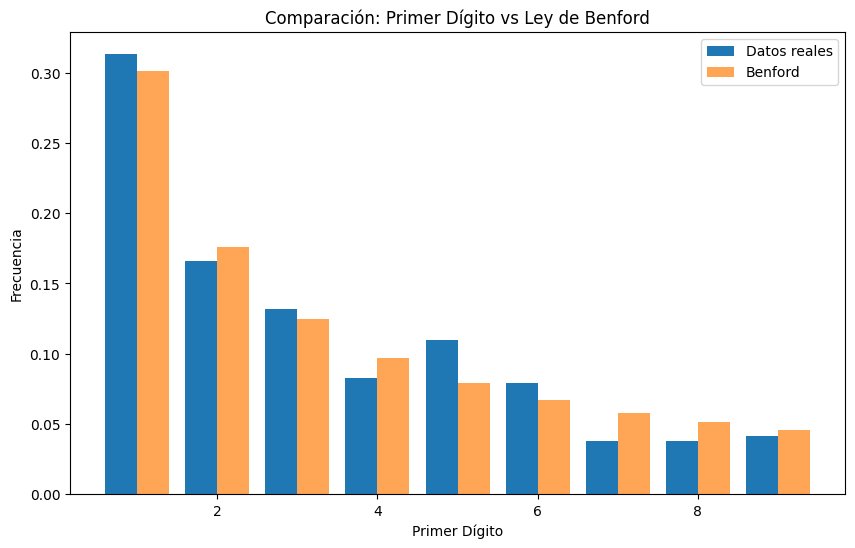

In [14]:
# Distribución teórica
benford = {d: np.log10(1 + 1/d) for d in range(1,10)}
benford = pd.Series(benford)

# Gráfico comparativo
plt.figure(figsize=(10,6))
plt.bar(freq.index - 0.2, freq.values, width=0.4, label="Datos reales")
plt.bar(benford.index + 0.2, benford.values, width=0.4, label="Benford", alpha=0.7)

plt.title("Comparación: Primer Dígito vs Ley de Benford")
plt.xlabel("Primer Dígito")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


En la mayoría de los casos verás que **la distribución se acerca bastante a lo esperado por la Ley de Benford**.

---

## 🧪 Ejemplo adicional: precios aleatorios multiplicativos

Los datos multiplicativos suelen seguir Benford:

/Users/patricio/Documents/kibernum/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


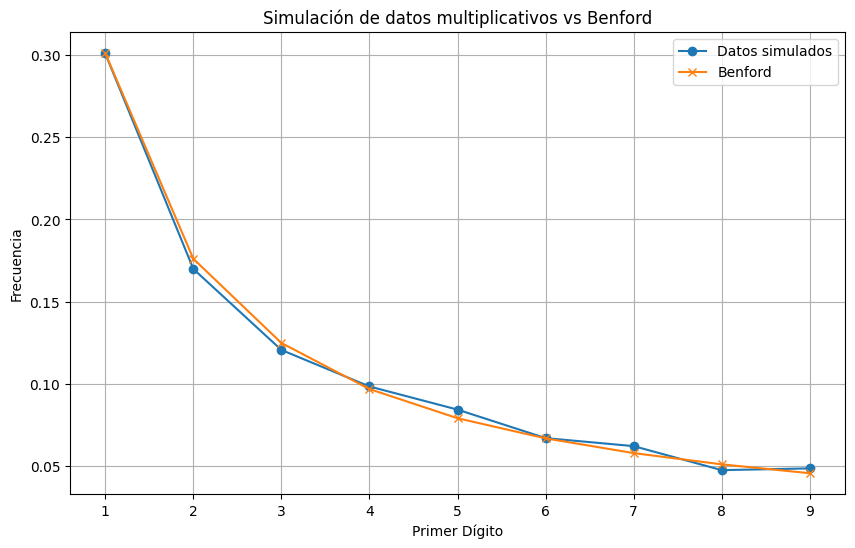

In [15]:
np.random.seed(42)

# Generamos datos con crecimiento multiplicativo
valores = np.cumprod(1 + np.random.rand(10000))

first_digits = pd.Series([primer_digito(v) for v in valores]).value_counts(normalize=True).sort_index()

# Graficamos
plt.figure(figsize=(10,6))
plt.plot(first_digits.index, first_digits.values, marker="o", label="Datos simulados")
plt.plot(benford.index, benford.values, marker="x", label="Benford")
plt.title("Simulación de datos multiplicativos vs Benford")
plt.xlabel("Primer Dígito")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid()
plt.show()



Este tipo de datos casi siempre sigue muy bien la Ley de Benford.

---

## 🔍 5. ¿Para qué sirve la Ley de Benford?

### ✔ Auditoría y detección de fraude

Cuando los datos contables, financieros o electorales **se desvían mucho** de Benford, puede indicar:

* Fraude contable
* Datos manipulados
* Errores de digitación
* Simulación artificial de números

La ley se usa como **screening inicial**, no como prueba definitiva.

---


## Aplicaciones
Fuente: https://www.estadisticaparatodos.es/taller/benford/utililidad.html

> Como los números que empiezan por «1» aparecen tan a menudo, es posible descubrir a tramposillos (con los impuestos, con los deberes de clase, etc.) simplemente comprobando si los números que se inventan tienen esa desviación hacia los que comienzan por «1» tan frecuentemente como los otros, o no.

**A la caza del fraude fiscal con Benford**

El Dr. Mark Nigrini, un profesor de contabilidad de Dallas, ha creado un programa informático para detectar en qué medida algunos datos suministrados encajan con la Ley de Benford.
Si alguien trata de falsificar, por ejemplo, su declaración de la renta, irremediablemente tendrá que inventar algún dato. Al intentarlo, la tendencia de la gente es utilizar demasiados números que comienzan por dígitos a mitad de la escala, 5, 6, 7, y pocos que empiezan por 1. Esta violación de la Ley de Benford no implica necesariamente fraude, pero sí constituye un buen indicio para justificar una inspección más detallada.
Por ejemplo, la Hacienda de EE.UU determinó que si una cifra empieza por tres y aparece el 40% de las veces, en vez del 12,5%, hay motivos para investigar el fraude fiscal. Esta técnica ha sido probada con un gran éxito en la oficina del fiscal del distrito de Brooklyn de New York.

**Detección de irregularidades en Auditorías Internas**

El Análisis de Frecuencia Digital ha surgido en los últimos años como una potente herramienta analítica en la detección de irregularidades y fraudes, y en la categorización de grupos, sucursales, áreas o cuentas de riesgo. Se trata de un análisis cada vez más utilizado por las Direcciones de Auditoría Interna más modernas, en la lucha contra el fraude.

**Distribuir espacio del disco duro**

Se podría ahorrar tiempo, dinero y medios si los sistemas informáticos se manejaran de forma más eficaz. Por ejemplo, para optimizar el acceso a espacio de almacenamiento en los ordenadores podemos ubicar juntos los números de acuerdo a las proporciones determinadas por la ley pues serán los datos más accedidos. Un equipo de Friburgo, Alemania está trabajando en la idea de distribuir espacio del disco duro según la Ley de Benford.
Irregularidades en casos clínicos.
Unos científicos belgas investigan si la Ley de Benford puede usarse para detectar irregularidades en casos clínicos.

**Modelos demográficos**

La buena correlación existente entre las estadísticas poblacionales y la Ley de Benford significa que puede usarse para verificar modelos demográficos.

**Aplicaciones al Referéndum Revocatorio en Venezuela**

La Universidad de Puerto Rico ha realizado un estudio utilizando la Ley de Benford para detectar manipulaciones en los votos de las mesas automatizadas del referéndum revocatorio en Venezuela.


## 🧾 Conclusiones clave

* La **Ley de Benford** describe cómo se distribuyen los **primeros dígitos** en muchos datos reales.

* Los dígitos menores son **mucho más frecuentes** que los grandes.

* Funciona muy bien con datos **naturales y no acotados**, especialmente de crecimiento multiplicativo.

* Es una herramienta poderosa en **auditoría, data science y análisis de inconsistencias**.

* Python permite testear fácilmente la ley con conjuntos de datos reales.
